# Exploracion del Dataset Simulado VAK

Material Engagement - Version Beta (Dataset Simulado).

Este notebook documenta la validacion y el analisis exploratorio del dataset
`data/dataset_simulado.csv` usado para entrenar el clasificador VAK
(Visual / Auditivo / Kinestesico). Cubre la Fase 1, tarea 4 del plan:
balance de clases, estadisticas descriptivas y visualizacion de la distribucion
de features.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from preprocess import CATEGORICAL_FEATURES, NUMERIC_FEATURES, TARGET_COLUMN

sns.set_theme(style='whitegrid')
DATA_PATH = os.path.join('..', 'data', 'dataset_simulado.csv')
REPORTS_DIR = os.path.join('..', 'reports')

df = pd.read_csv(DATA_PATH)
print('Dimensiones:', df.shape)
df.head()

Dimensiones: (500, 21)


,student_id,visual_score,auditory_score,kinesthetic_score,options_selection,preferred_content_type,avg_response_time,total_quest_time,n_response_changes,n_clicks,...,engagement_level,completion_level,content_repetition,response_consistency,age,academic_grade,number_of_sessions,session_duration,usage_frequency,target_vak_label
0,1001,3,14,2,A,audio,20.97,694.45,4,81,...,0.732,0.922,2,0.652,11,3ro Primaria,11,18.49,6.09,Auditivo
1,1002,12,2,7,B,image,20.46,173.73,1,34,...,0.689,0.964,0,0.941,10,2do Secundaria,6,8.59,1.22,Visual
2,1003,5,7,9,B,image,28.16,707.26,4,106,...,0.930,0.929,2,0.624,17,5to Secundaria,12,43.46,6.66,Kinestesico
3,1004,13,2,4,D,image,18.97,213.32,0,49,...,0.582,0.842,2,0.745,14,6to Primaria,2,37.29,3.25,Visual
4,1005,9,7,3,A,video,16.32,425.27,0,33,...,0.613,0.992,3,0.738,14,4to Primaria,2,23.39,0.56,Visual


## 1. Tipos de datos y nulos

In [2]:
df.info()
print('\nNulos por columna:')
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().any().any() else 'Sin nulos')

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              500 non-null    int64  
 1   visual_score            500 non-null    int64  
 2   auditory_score          500 non-null    int64  
 3   kinesthetic_score       500 non-null    int64  
 4   options_selection       500 non-null    str    
 5   preferred_content_type  500 non-null    str    
 6   avg_response_time       500 non-null    float64
 7   total_quest_time        500 non-null    float64
 8   n_response_changes      500 non-null    int64  
 9   n_clicks                500 non-null    int64  
 10  navigation_sequence     500 non-null    str    
 11  engagement_level        500 non-null    float64
 12  completion_level        500 non-null    float64
 13  content_repetition      500 non-null    int64  
 14  response_consistency    500 non-null    float64
 15  

## 2. Balance de clases

Se verifica la distribucion de la etiqueta VAK. El plan original buscaba 100 por
estilo; el dataset real presenta cierto desbalance que se corrige con SMOTE en
`train.py`.

target_vak_label
Visual         205
Auditivo       165
Kinestesico    130
Name: count, dtype: int64


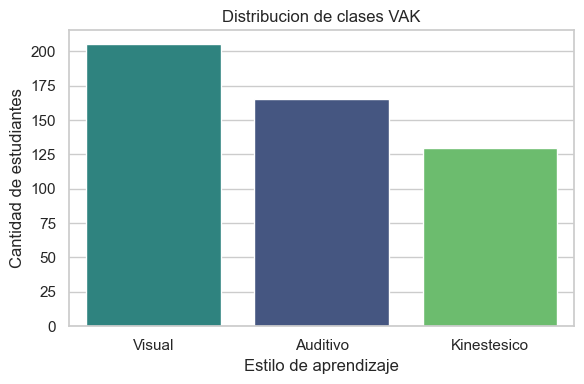

In [3]:
counts = df[TARGET_COLUMN].value_counts()
print(counts)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET_COLUMN, order=counts.index, hue=TARGET_COLUMN, palette='viridis', legend=False)
plt.title('Distribucion de clases VAK')
plt.xlabel('Estilo de aprendizaje')
plt.ylabel('Cantidad de estudiantes')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'class_distribution.png'), dpi=120)
plt.show()

## 3. Estadisticas descriptivas de variables numericas

In [4]:
df[NUMERIC_FEATURES].describe().T

,count,mean,std,min,25%,50%,75%,max
visual_score,500.0,7.336000,3.738858,2.000,4.0000,7.000,11.00000,14.000
auditory_score,500.0,6.782000,3.698897,2.000,4.0000,6.000,10.00000,14.000
kinesthetic_score,500.0,6.298000,3.469477,2.000,4.0000,6.000,8.25000,14.000
avg_response_time,500.0,22.021600,8.923199,8.160,15.7050,20.540,27.72500,44.830
total_quest_time,500.0,451.686600,182.846393,135.600,310.6875,426.340,595.73500,917.800
n_response_changes,500.0,2.528000,1.973069,0.000,1.0000,2.000,4.00000,7.000
n_clicks,500.0,65.914000,24.969131,20.000,46.7500,63.000,87.00000,118.000
engagement_level,500.0,0.774578,0.106561,0.553,0.7005,0.771,0.85625,0.996
completion_level,500.0,0.874630,0.072636,0.701,0.8240,0.876,0.93400,1.000
content_repetition,500.0,2.462000,1.683516,0.000,1.0000,2.000,4.00000,5.000


## 4. Puntajes VAK por estilo real

Se espera que cada estilo muestre su puntaje correspondiente mas alto.

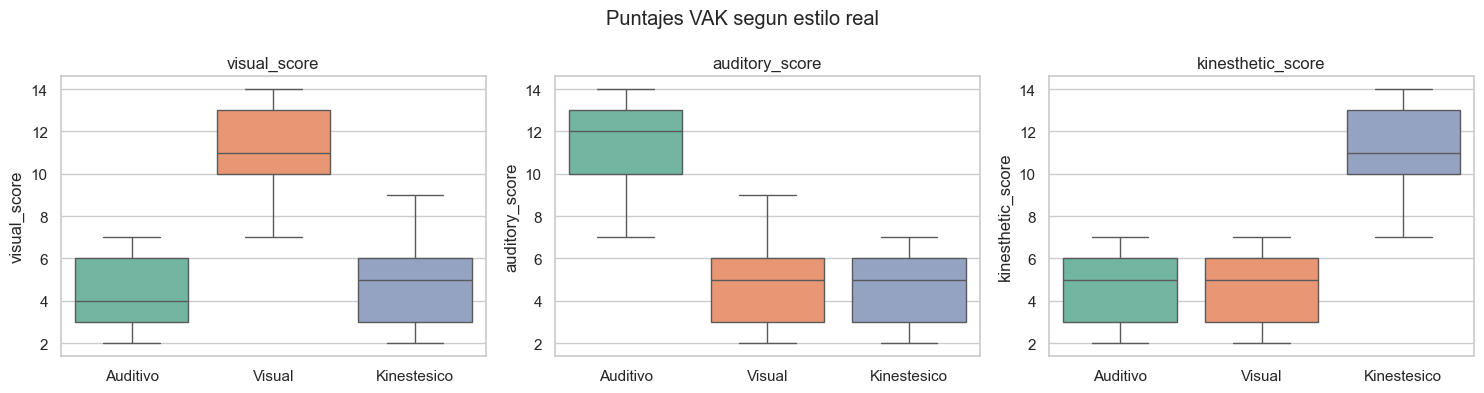

In [5]:
score_cols = ['visual_score', 'auditory_score', 'kinesthetic_score']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, score_cols):
    sns.boxplot(data=df, x=TARGET_COLUMN, y=col, hue=TARGET_COLUMN, palette='Set2', ax=ax, legend=False)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Puntajes VAK segun estilo real')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'vak_scores_by_class.png'), dpi=120)
plt.show()

## 5. Correlacion entre variables numericas

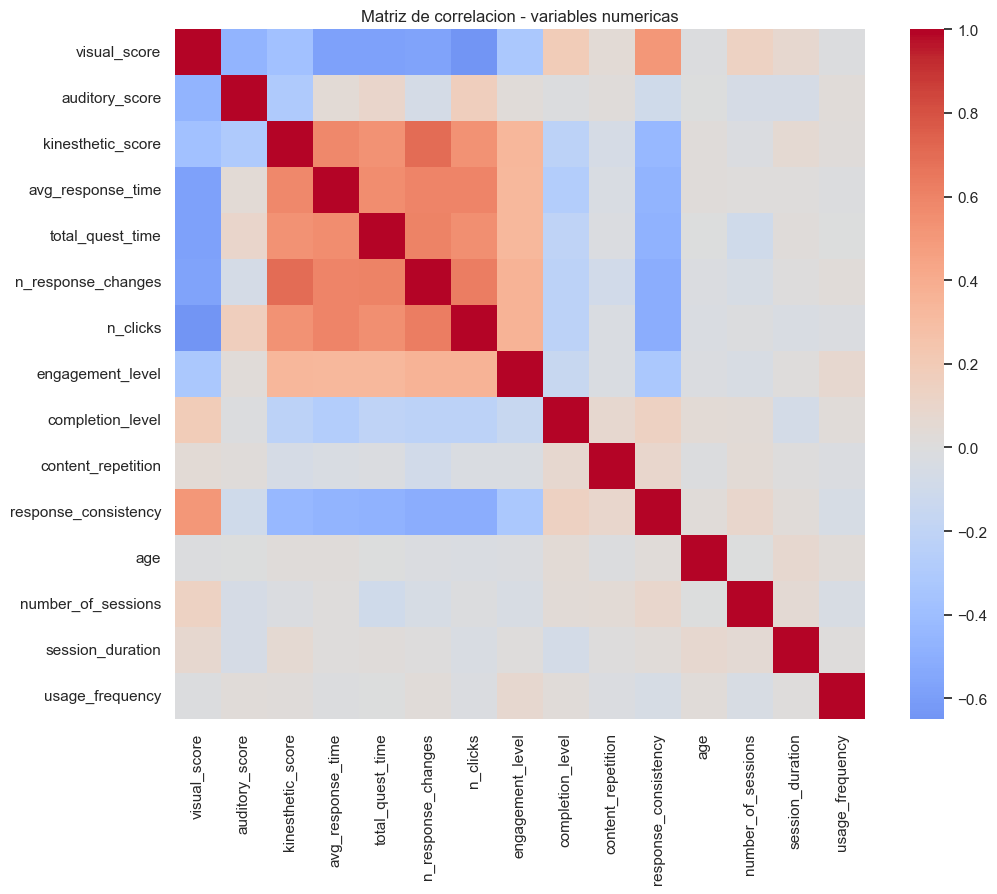

In [6]:
plt.figure(figsize=(11, 9))
corr = df[NUMERIC_FEATURES].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=True)
plt.title('Matriz de correlacion - variables numericas')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'correlation_matrix.png'), dpi=120)
plt.show()

## 6. Variables categoricas

In [7]:
for col in CATEGORICAL_FEATURES:
    print(f'--- {col} ---')
    print(df[col].value_counts(), '\n')

--- options_selection ---
options_selection
A    134
C    131
D    125
B    110
Name: count, dtype: int64 

--- preferred_content_type ---
preferred_content_type
image       132
video       127
audio       107
exercise     78
text         56
Name: count, dtype: int64 

--- navigation_sequence ---
navigation_sequence
linear             186
back_and_forth     143
skip_and_return    121
random              50
Name: count, dtype: int64 

--- academic_grade ---
academic_grade
2do Primaria      54
3ro Secundaria    52
6to Primaria      51
4to Primaria      49
3ro Primaria      48
4to Secundaria    46
1ro Primaria      42
5to Primaria      42
1ro Secundaria    40
2do Secundaria    38
5to Secundaria    38
Name: count, dtype: int64 



## Conclusiones

- El dataset contiene 500 registros con 20 variables predictoras + etiqueta VAK.
- Las clases estan desbalanceadas (Visual > Auditivo > Kinestesico); `train.py`
  aplica SMOTE sobre el conjunto de entrenamiento para balancearlas.
- Los puntajes `visual_score`, `auditory_score` y `kinesthetic_score` son los
  predictores mas discriminativos, como confirma el feature importance del modelo.
- No hay valores nulos relevantes; el pipeline imputa con mediana/categoria por
  defecto como salvaguarda.